In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
import numpy as np
import matplotlib.pyplot as plt


('./drive/MyDrive/lab_5/theory/data/train/ants/1030023514_aad5c608f9.jpg', 0)
244


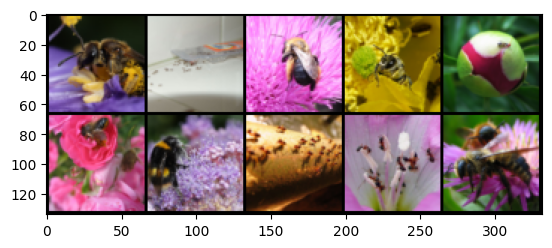

In [ ]:
# Сначала определим на каком устройстве будем работать - GPU или CPU
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')

# Затем загружаем данные
# Работа с данными в pytorch осуществляется через класс datasets
# Этот класс содержит основную информацию об используемом наборе данных
# пути расположения файлов, метки классов, разметки и аннотации
# для работы с собственными данными нужно создать свой dataset из каталога с
# файлами или можно воспользоваться одним из предустановленных наборов данных
# полный список имеющихся dataset-ов можно посмотреть по ссылке
# https://pytorch.org/vision/stable/datasets.html

# Затем загружаем данные (взяты отсюда https://download.pytorch.org/tutorial/hymenoptera_data.zip)
# Задача классификации изображений предполагает что изображения хранятся
# в специально организованной иерархии каталогов. Какталог data содержит каталоги train и test.
# train - обучающая выборка, на ней будет происходить обучение,
# test - тестовая выборка, по ней будет контролироваться итоговая ошибка после обучения.
# Разделение имеющегося набора данных на тестовую и обучающую выборку - стандартный прием,
# позволяющий контролировать переобучение, когда сеть запоминает обучающие данные и на
# обучающем наборе ошибка низкая, но при этом с новые данные, которых не было на обучении,
# сеть правильно классифицировать не может. Если ошибка на тренировочном и тестовом наборе данных
#  существенно отличается, это говорит о переобучении.
# Далее, каждый из катологов train и test содержит каталоги с
# названиями классов (в нашей задаче bees и ants), а уже в них хранятся изображения
# объектов соответствующего класса.



# Создадим отдельно обучающий набор.
# Параметр transform указывает какие преобразования с данными необходимо проделать при загрузке
# это могут быть обрезка, повороты, изменения яркости и др.

# Так как простые сети работают с изображениями фиксированного размера,
# то наши изображения необходимо смасштабировать и преобразовать в тензор
data_transforms = transforms.Compose([
                        transforms.Resize(68),
                        transforms.CenterCrop(64),
                        transforms.ToTensor()])

# ImageFolder указывает что датасет загружается из каталога.
train_dataset = torchvision.datasets.ImageFolder(root='./drive/MyDrive/lab_5/theory/data/train',
                                                 transform=data_transforms)


# И отдельно создадим тестовый набор.
test_dataset = torchvision.datasets.ImageFolder(root='./drive/MyDrive/lab_5/theory/data/test',
                                             transform=data_transforms)


# посмотрим какие классы содержатся в наборе
train_dataset.classes

# сохраним названия этих классов
class_names = train_dataset.classes

# Список изображений можно получить следующим образом:
train_set = train_dataset.samples
print(train_set[1]) #  каждая строка списка содержит путь к изображению и метку класса

# посмотрим на размер нашего набора данных
print(len(train_set))

# В реальных задачах объем данных может быть очень большим, поэтому класс datasets
# содержит только описание набора данных и путь к ним
# Непосредственную загрузку данных в оперативную память осуществляет класс dataloader

batch_size = 10 # данные будут загружаться частями (batch)

# параметр shuffle указывает что данные будут выбираься случайно,
# num_workers - указывает сколько процессов (условно ядер процессора) будет
# задействовано при загрузке (т.к. при загрузке еще выполняются преобразования transform,
# то это может быть вычислительно затратно)
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size,
                                    shuffle=True,  num_workers=2)


test_loader  = torch.utils.data.DataLoader(test_dataset, batch_size=batch_size,
                                    shuffle=False, num_workers=2)


# Загрузим одну порцию данных.
# Каждое обращение к DataLoader возвращает изображения и их классы
inputs, classes = next(iter(train_loader))
inputs.shape # 10 изображений, 3 канала (RGB), размер каждого 224х224 пикселя

# построим на картинке
img = torchvision.utils.make_grid(inputs, nrow = 5) # метод делает сетку из картинок
img = img.numpy().transpose((1, 2, 0)) # для отображения через matplotlib
plt.imshow(img)


In [ ]:
# Теперь можно переходить к созданию сети
# Для этого будем использовать как и ранее метод Sequential
# который объединит несколько слоев в один стек
class CnNet(nn.Module):
    def __init__(self, num_classes=10):
        nn.Module.__init__(self)
        self.layer1 = nn.Sequential(
        # первый сверточный слой с ReLU активацией и maxpooling-ом
            nn.Conv2d(3, 16, kernel_size=7, stride=1, padding=2), # 3 канала, 16 фильтров, размер ядра 7
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2))
        # второй сверточный слой
        # количество каналов второго слоя равно количеству фильтров предыдущего слоя
        self.layer2 = nn.Sequential(
            nn.Conv2d(16, 32, kernel_size=5, stride=1, padding=2),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2))
        # третий сверточный слой
        # ядро фильтра от слоя к слою уменьшается
        self.layer3 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=2),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2))
        # классификационный слой имеет нейронов: количество фильтров * размеры карты признаков
        self.fc = nn.Linear(8*8*64, num_classes)

    def forward(self, x):
        out = self.layer1(x)
        out = self.layer2(out)
        out = self.layer3(out)
        out = out.reshape(out.size(0), -1) # флаттеринг
        out = self.fc(out)
        return out


In [ ]:
# Количество классов
num_classes = 2

# создаем экземпляр сети
net = CnNet(num_classes).to(device)

# Задаем функцию потерь и алгоритм оптимизации
lossFn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(net.parameters(), lr=0.01)


In [ ]:
import time
t = time.time()

# Зададим количество эпох обучения (каждая эпоха прогоняет обучающий набор 1 раз)
num_epochs = 50
save_loss = []
for epoch in range(num_epochs):
    for i, (images, labels) in enumerate(train_loader):
        images = images.to(device)
        labels = labels.to(device)

        # прямой проход
        outputs = net(images)

        # вычисление значения функции потерь
        loss = lossFn(outputs, labels)

        # Обратный проход (вычисляем градиенты)
        optimizer.zero_grad()
        loss.backward()

        # делаем шаг оптимизации весов
        optimizer.step()

        # сохраняем loss
        save_loss.append(loss.item())
        # выводим немного диагностической информации
        if i%100==0:
            print('Эпоха ' + str(epoch) + ' из ' + str(num_epochs) + ' Шаг ' +
                  str(i) + ' Ошибка: ', loss.item())

print(time.time() - t)



Эпоха 0 из 50 Шаг 0 Ошибка:  0.6968904733657837
Эпоха 1 из 50 Шаг 0 Ошибка:  0.689289391040802
Эпоха 2 из 50 Шаг 0 Ошибка:  0.6464554071426392
Эпоха 3 из 50 Шаг 0 Ошибка:  0.683277428150177
Эпоха 4 из 50 Шаг 0 Ошибка:  0.6817818880081177
Эпоха 5 из 50 Шаг 0 Ошибка:  0.7207885384559631
Эпоха 6 из 50 Шаг 0 Ошибка:  0.6872037649154663
Эпоха 7 из 50 Шаг 0 Ошибка:  0.6661081314086914
Эпоха 8 из 50 Шаг 0 Ошибка:  0.6569393873214722
Эпоха 9 из 50 Шаг 0 Ошибка:  0.6175047755241394
Эпоха 10 из 50 Шаг 0 Ошибка:  0.6603735089302063
Эпоха 11 из 50 Шаг 0 Ошибка:  0.517095685005188
Эпоха 12 из 50 Шаг 0 Ошибка:  0.6276370286941528
Эпоха 13 из 50 Шаг 0 Ошибка:  0.6751511693000793
Эпоха 14 из 50 Шаг 0 Ошибка:  0.7268036007881165
Эпоха 15 из 50 Шаг 0 Ошибка:  0.7191920280456543
Эпоха 16 из 50 Шаг 0 Ошибка:  0.5917671322822571
Эпоха 17 из 50 Шаг 0 Ошибка:  0.7588834762573242
Эпоха 18 из 50 Шаг 0 Ошибка:  0.6259430646896362
Эпоха 19 из 50 Шаг 0 Ошибка:  0.7303705215454102
Эпоха 20 из 50 Шаг 0 Ошибка:  0.4

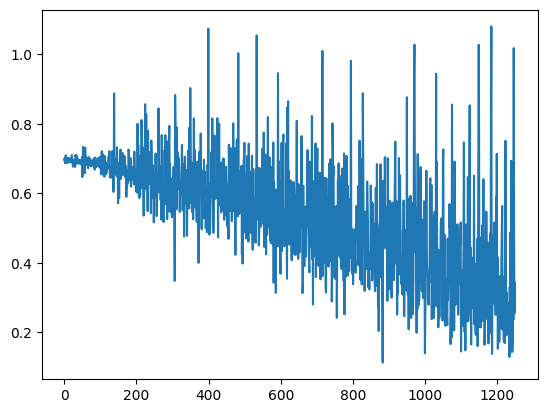

In [ ]:
# Посмотрим как уменьшался loss в процессе обучения
plt.figure()
plt.plot(save_loss)

In [ ]:
# Посчитаем точность нашей модели: количество правильно классифицированных картинок
# поделенное на общее количество тестовых примеров
correct_predictions = 0
num_test_samples = len(test_dataset)


In [ ]:
with torch.no_grad(): # отключим вычисление граиентов, т.к. будем делать только прямой проход
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)
        pred = net(images) # делаем предсказание по пакету
        _, pred_class = torch.max(pred.data, 1) # выбираем класс с максимальной оценкой
        correct_predictions += (pred_class == labels).sum().item() # сравниваем ответ с правильной меткой


print('Точность модели: ' + str(100 * correct_predictions / num_test_samples) + '%')


Точность модели: 62.745098039215684%


In [ ]:
# Нашу модель можно сохранить в файл для дальнейшего использования
torch.save(net.state_dict(), 'CnNet.ckpt')


In [ ]:
# определенного размера, то наши изображения необходимо к ним преобразовать
data_transforms = transforms.Compose([
                        transforms.Resize(256),
                        transforms.CenterCrop(224),
                        transforms.ToTensor(),
                        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                             std=[0.229, 0.224, 0.225] )
    ])


In [ ]:
# Пересоздадим датасеты с учетом новых размеров и нормировки яркости
train_dataset = torchvision.datasets.ImageFolder(root='./drive/MyDrive/lab_5/theory/data/train',
                                                 transform=data_transforms)
test_dataset = torchvision.datasets.ImageFolder(root='./drive/MyDrive/lab_5/theory/data/test',
                                             transform=data_transforms)


In [ ]:
batch_size = 10

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size,
                                    shuffle=True,  num_workers=2)


test_loader  = torch.utils.data.DataLoader(test_dataset, batch_size=batch_size,
                                    shuffle=False, num_workers=2)


In [ ]:
# В качестве донора возьмем преобученную на ImageNet наборе сеть AlexNet
# Список доступных предобученных сетей можно посмотреть тут https://pytorch.org/vision/main/models.html
net = torchvision.models.alexnet(pretrained=True)


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/alexnet-owt-7be5be79.pth" to /root/.cache/torch/hub/checkpoints/alexnet-owt-7be5be79.pth


100%|██████████| 233M/233M [00:01<00:00, 158MB/s]


In [ ]:
# можно посмотреть структуру этой сети
print(net)


AlexNet(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(11, 11), stride=(4, 4), padding=(2, 2))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(64, 192, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (4): ReLU(inplace=True)
    (5): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(192, 384, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU(inplace=True)
    (8): Conv2d(384, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): ReLU(inplace=True)
    (10): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (avgpool): AdaptiveAvgPool2d(output_size=(6, 6))
  (classifier): Sequential(
    (0): Dropout(p=0.5, inplace=False)
    (1): Linear(in_features=9216, out_features=4096, bias=True)
 

In [ ]:
# Так как веса feature_extractor уже обучены, нам нужно их "заморозить", чтобы
# быстрее научился наш классификатор
#  для этого отключаем у всех слоев (включая слои feature_extractor-а) градиенты
for param in net.parameters():
    param.requires_grad = False


In [ ]:
# Выходной слой AlexNet содержит 1000 нейронов (по количеству классов в ImageNet).
# Нам нужно его заменить на слой, содержащий только 2 класса.

num_classes = 2

new_classifier = net.classifier[:-1] # берем все слой классификатора кроме последнего
new_classifier.add_module('fc',nn.Linear(4096,num_classes))# добавляем последним слой с двумя нейронами на выходе
net.classifier = new_classifier # меняем классификатор сети


In [ ]:
net = net.to(device)

# проверим эффективность новой сети
correct_predictions = 0
num_test_samples = len(test_dataset)

with torch.no_grad(): # отключим вычисление граиентов, т.к. будем делать только прямой проход
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)
        pred = net(images) # делаем предсказание по пакету
        _, pred_class = torch.max(pred.data, 1) # выбираем класс с максимальной оценкой
        correct_predictions += (pred_class == labels).sum().item()

print('Точность модели: ' + str(100 * correct_predictions / num_test_samples) + '%')
# явно требуется обучение


Точность модели: 39.869281045751634%


In [ ]:
num_epochs = 2
lossFn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(net.parameters(), lr=0.01)

# создаем цикл обучения и замеряем время его выполнения
t = time.time()
save_loss = []
for epoch in range(num_epochs):
    for i, (images, labels) in enumerate(train_loader):
        images = images.to(device)
        labels = labels.to(device)
        # прямой проход
        outputs = net(images)
        # вычисление значения функции потерь
        loss = lossFn(outputs, labels)
         # Обратный проход (вычисляем градиенты)
        optimizer.zero_grad()
        loss.backward()
        # делаем шаг оптимизации весов
        optimizer.step()
        save_loss.append(loss.item())
        # выводим немного диагностической информации
        if i%100==0:
            print('Эпоха ' + str(epoch) + ' из ' + str(num_epochs) + ' Шаг ' +
                  str(i) + ' Ошибка: ', loss.item())

print(time.time() - t)


Эпоха 0 из 2 Шаг 0 Ошибка:  0.8375584483146667
Эпоха 1 из 2 Шаг 0 Ошибка:  0.006635069847106934
5.148999452590942


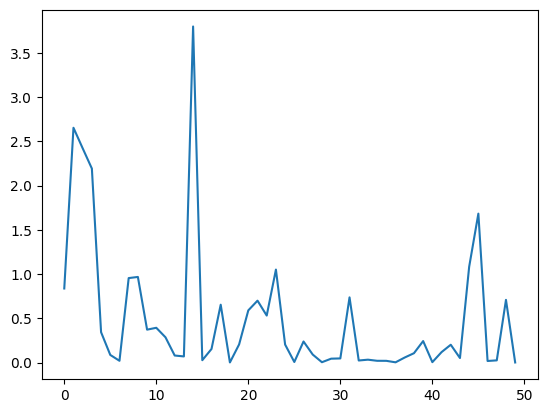

In [ ]:
# Посмотрим как уменьшался loss в процессе обучения
plt.figure()
plt.plot(save_loss)


In [ ]:
# Еще раз посчитаем точность нашей модели
correct_predictions = 0
num_test_samples = len(test_dataset)

with torch.no_grad(): # отключим вычисление граиентов, т.к. будем делать только прямой проход
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)
        pred = net(images) # делаем предсказание по пакету
        _, pred_class = torch.max(pred.data, 1) # выбираем класс с максимальной оценкой
        correct_predictions += (pred_class == labels).sum().item()

print('Точность модели: ' + str(100 * correct_predictions / num_test_samples) + '%')
# уже лучше


Точность модели: 86.27450980392157%


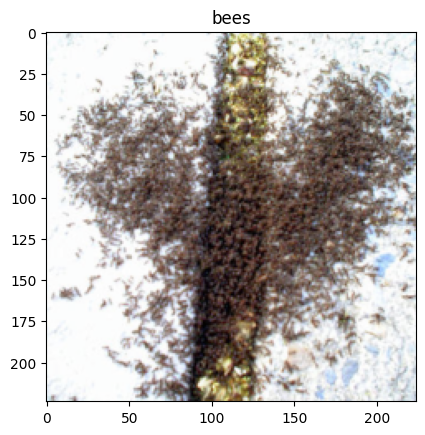

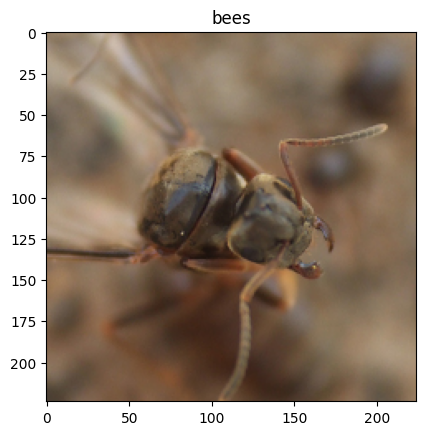

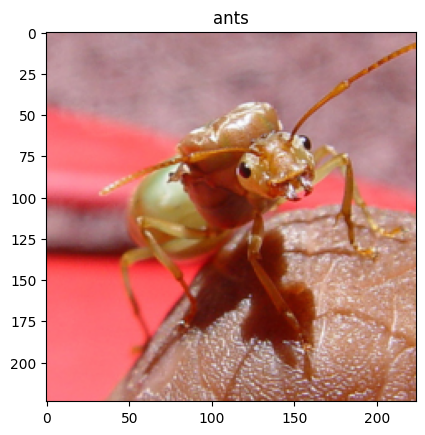

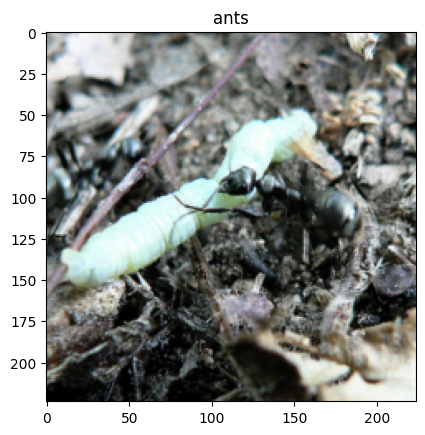

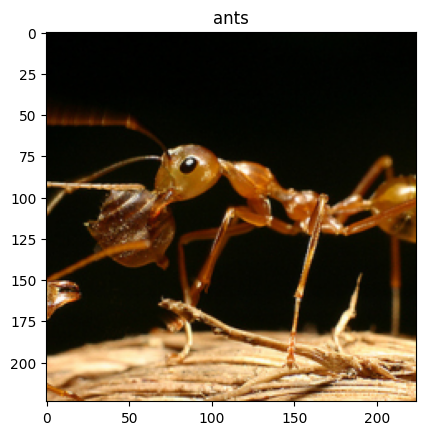

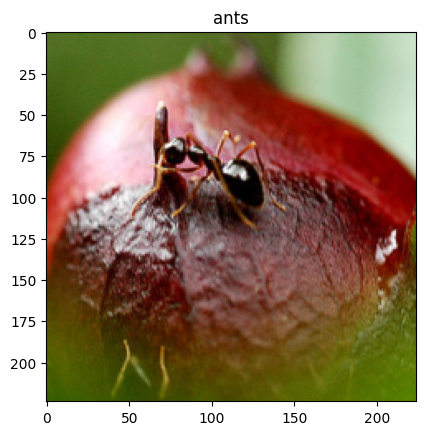

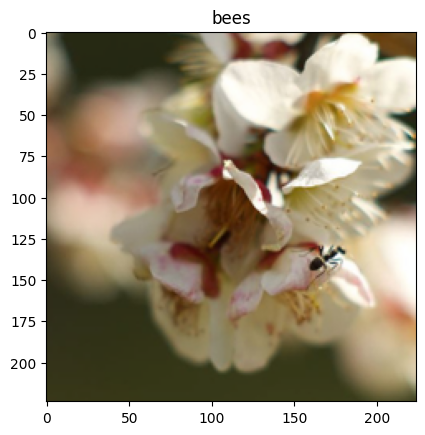

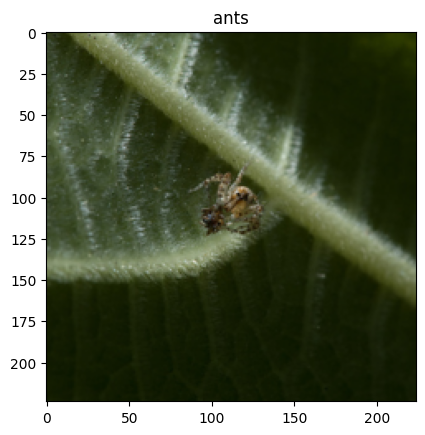

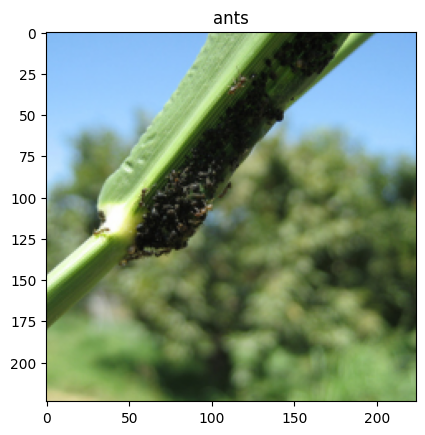

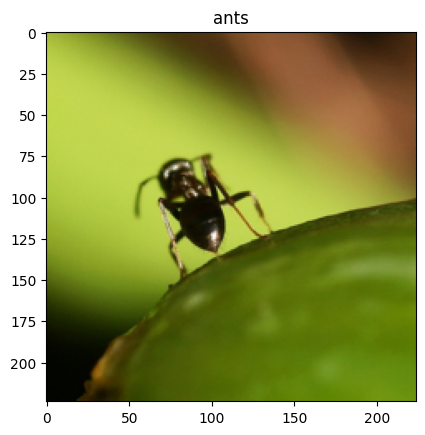

In [ ]:
# Реализуем отображение картинок и их класса, предсказанного сетью
inputs, classes = next(iter(test_loader))
pred = net(inputs.to(device))
_, pred_class = torch.max(pred.data, 1)

for i,j in zip(inputs, pred_class):
    img = i.numpy().transpose((1, 2, 0))
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    img = std * img + mean
    img = np.clip(img, 0, 1)
    plt.imshow(img)
    plt.title(class_names[j])
    plt.pause(2)
